# 01 - Load, clean, and save OTP data

One-time load/clean of raw OTP data -- subsequent notebooks read the saved
result from `data/`, no need to re-run this unless cleaning logic changes or new records are pulled.

In [1]:
# only need load_dataset for the commented-out HuggingFace pull below;
# not in this project's requirements.txt since path inactive
# (we already have 1_df_raw.parquet)

# from datasets import load_dataset

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

BASEPATH = "../data"

## Load data

Uncomment the HuggingFace pull below if adjusting cleaning logic or pulling new records. Otherwise, reads the existing raw data from `data/`

In [2]:
# load the full train dataset (57 mb, 25mil rows) via HuggingFace directory
# split = "train" refers to HuggingFace dataset split name (not train/test)

# ds = load_dataset("fulldecent/septa-regionalrail-otp", split = "train")

# save raw data to path folder if re running. otherwise read_parquet() below

# ds.to_parquet(f"{BASEPATH}/1_df_raw.parquet")
# df_orig = ds.to_pandas()

# read saved raw OTP data ^
df_orig = pd.read_parquet(f"{BASEPATH}/1_df_raw.parquet")

# Clean data

In [3]:
# remove rows w/ missing lateness vals
df = df_orig[df_orig["lateness"] != 999].copy()

# init cleanup
# convert to date object
df["service_date"] = pd.to_datetime(df["service_date"])
df = df.sort_values(["service_date", "time"]).reset_index(drop = True)

# septa's service day runs 3a -> 3a next day instead of midnight
# create additional column to correct calendar day
df["datetime"] = pd.to_datetime(df["service_date"].astype(str) + " " + df["time"])
mask = df["time"] < "03:00:00"
df.loc[mask, "datetime"] += pd.Timedelta(days = 1)

In [4]:
# duplicate check
print("Duplicate rows:", df.duplicated().sum())

# look into duplicate instances
display(df[df.duplicated(keep = False)]
        .sort_values(["service_date", "time", "train_number"])
        .head(20))

# look into specific days w duplicates
display(df[df.duplicated()]["service_date"]
        .value_counts()
        .sort_index())
# duplicated entries appear to all be from New Years Day in 2012, 2013, 2014, 2017
# maybe API issues -- only 12k rows so I'll drop

df = df.drop_duplicates().reset_index(drop = True)

Duplicate rows: 12285


,service_date,time,train_number,lateness,datetime
907199,2012-01-01,00:00:00,576,2,2012-01-02 00:00:00
907200,2012-01-01,00:00:00,576,2,2012-01-02 00:00:00
907201,2012-01-01,00:00:00,6237,29,2012-01-02 00:00:00
907202,2012-01-01,00:00:00,6237,29,2012-01-02 00:00:00
907203,2012-01-01,00:00:00,738,7,2012-01-02 00:00:00
907204,2012-01-01,00:00:00,738,7,2012-01-02 00:00:00
907205,2012-01-01,00:02:00,576,0,2012-01-02 00:02:00
907206,2012-01-01,00:02:00,576,0,2012-01-02 00:02:00
907207,2012-01-01,00:02:00,6237,31,2012-01-02 00:02:00
907208,2012-01-01,00:02:00,6237,31,2012-01-02 00:02:00


service_date
2012-01-01    3147
2013-01-01    2715
2014-01-01    2922
2017-01-01    3501
Name: count, dtype: int64

In [5]:
print("Null values:")
df.isnull().sum() #none

Null values:


service_date    0
time            0
train_number    0
lateness        0
datetime        0
dtype: int64

In [6]:
print("Lateness dist:")
display(df["lateness"].describe().apply(lambda x: f"{x:.2f}")) # late distribution
# looking into crazy max value: view delays over 3h
print("\n Trains with delays > 3 hours:")
display(df[df["lateness"] > 180])

Lateness dist:


count    25103705.00
mean            4.71
std             8.83
min             0.00
25%             1.00
50%             2.00
75%             5.00
max          1436.00
Name: lateness, dtype: str


 Trains with delays > 3 hours:


,service_date,time,train_number,lateness,datetime
5584255,2017-04-23,01:02:01,0,720,2017-04-24 01:02:01
5586628,2017-04-24,00:04:02,0,319,2017-04-25 00:04:02
5586637,2017-04-24,00:06:02,0,321,2017-04-25 00:06:02
5586643,2017-04-24,00:08:01,0,323,2017-04-25 00:08:01
5586650,2017-04-24,00:10:02,0,325,2017-04-25 00:10:02
...,...,...,...,...,...
24156934,2025-10-09,19:09:01,5447,192,2025-10-09 19:09:01
24156972,2025-10-09,19:10:01,5447,193,2025-10-09 19:10:01
24157008,2025-10-09,19:11:01,5447,195,2025-10-09 19:11:01
24157041,2025-10-09,19:12:01,5447,196,2025-10-09 19:12:01


We see ~1200 rows with what seem to be actual lateness values > 3h. Interestingly they don't actually appear to be data issues -- we can see the same trains on the same dates with climbing delays tracked in real time. Our extreme values seem legit

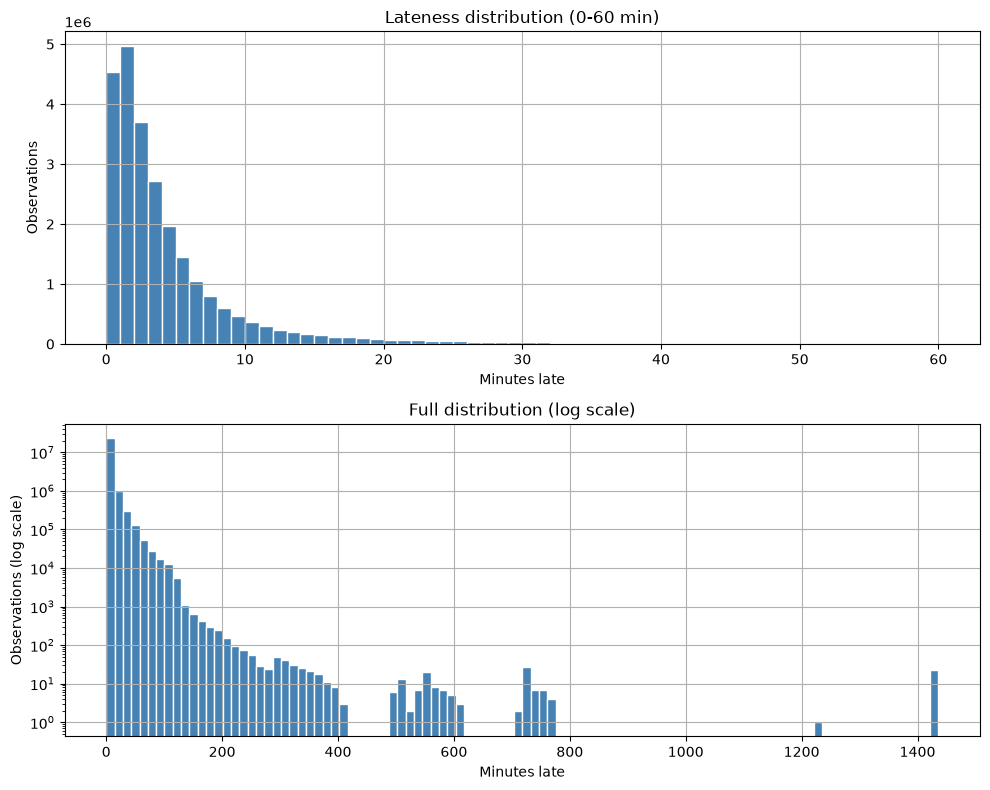

In [7]:
# plotting distribution of delays
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10, 8))

# base scale, capped at 60m, where we capture most of the values
df[df["lateness"] <= 60]["lateness"].hist(
    bins = 60, ax = ax1, color = "steelblue", edgecolor = "white")
ax1.set_title("Lateness distribution (0-60 min)")
ax1.set_xlabel("Minutes late")
ax1.set_ylabel("Observations")

# log scale, where we can see some of the extreme values
df["lateness"].hist(
    bins = 100, ax = ax2, color = "steelblue", edgecolor = "white")
ax2.set_yscale("log")
ax2.set_title("Full distribution (log scale)")
ax2.set_xlabel("Minutes late")
ax2.set_ylabel("Observations (log scale)")

plt.tight_layout()
plt.show()

Sharp dropoff after 25 minutes in top plot shows really long delays are pretty rare. Extreme delays seen in the bottom plot are likely a handful of specific incidents and not any consistent pattern (so I'd consider them valid).
Modeling should prob be done on log-transformed data given the extreme right tail here. Otherwise might want to convert to binary on time / late.

In [8]:
df["year"] = df["service_date"].dt.year
df["month"] = df["service_date"].dt.month
df["day_of_week"] = df["service_date"].dt.day_name()

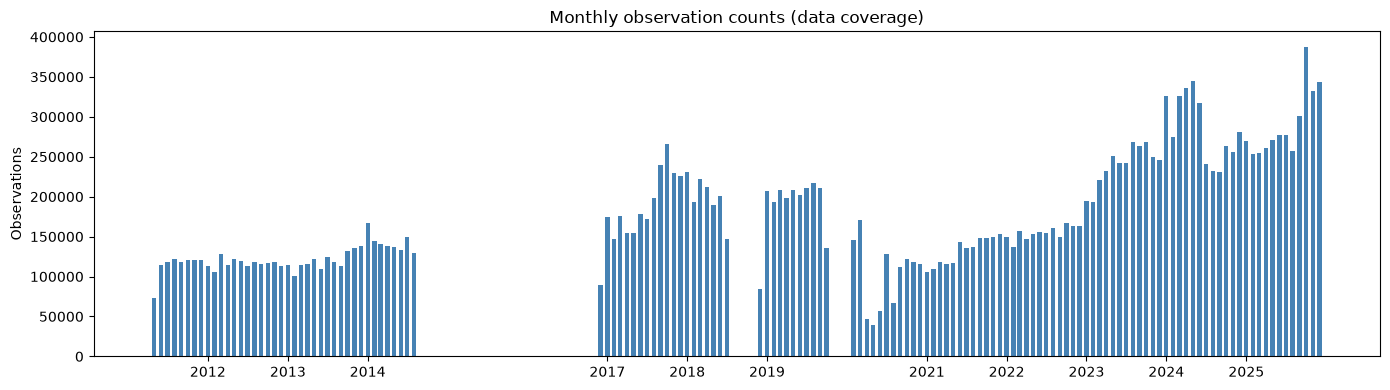

In [9]:
monthly_counts = (df.groupby(["year", "month"])
                     .size()
                     .reset_index(name = "count"))

monthly_counts["service_date"] = pd.to_datetime(
    monthly_counts[["year", "month"]]
    .assign(day = 1)) # assign all to day 1 of month for viz

years = monthly_counts[monthly_counts["month"] == 1]["service_date"]

fig, ax = plt.subplots(figsize = (14, 4))
ax.bar(monthly_counts["service_date"], monthly_counts["count"],
       width = 20, color = "steelblue", edgecolor = "none")

ax.set_title("Monthly observation counts (data coverage)")
ax.set_ylabel("Observations")
ax.set_xlabel("")
ax.set_xticks(years)
ax.set_xticklabels([str(y.year) for y in years], rotation = 0)

plt.tight_layout()
plt.show()

We see some major gaps in coverage.

Note: GTFS data releases (which I'll use to match train number -> GTFS data like line, schedule etc) begin in 2015, and we can see here that OTP data was not collected for most of 2014, 15, and 16 -- so I restrict window of observation to 2017 onwards and drop all data before then.

In [10]:
# restrict to 2017 on
df = df[df["year"] > 2016]

# investigating further gaps (2018/19/20)
monthly_counts = (df.groupby(["year", "month"])
                    .size()
                    .reset_index(name = "count"))
monthly_counts["service_date"] = pd.to_datetime(
    monthly_counts[["year", "month"]]
    .assign(day = 1)) # assign all to day 1 of month

# find missing months
full_range = pd.date_range(
    monthly_counts["service_date"].min(),
    monthly_counts["service_date"].max(),
    freq = "MS"
)
# never appearing
missing = full_range[~full_range.isin(monthly_counts["service_date"])]
print(f"Missing months: {missing.strftime('%Y-%m').tolist()}")

# flag low coverage months (below 5th pctile)
threshold = monthly_counts["count"].quantile(0.05)
low = monthly_counts[monthly_counts["count"] < threshold]

print(f"\nLow coverage months (below 5th percentile, {threshold:,.0f} obs):")
print(low[["service_date", "count"]].to_string(index = False))

Missing months: ['2018-08', '2018-09', '2018-10', '2018-11', '2019-11', '2019-12', '2020-01']

Low coverage months (below 5th percentile, 105,235 obs):
service_date  count
  2018-12-01  83894
  2020-04-01  46981
  2020-05-01  39063
  2020-06-01  57133
  2020-08-01  66283


In [11]:
low_months = set(low["service_date"])
mon = df["service_date"].dt.to_period("M").dt.to_timestamp()

# standard coverage - can filter only to these later on
df["period_flag"] = "normal"

# low coverage
df.loc[mon.isin(low_months), "period_flag"] = "low"

# Note: no rows from Aug 2018 thru Nov 2018
#                        or Nov 2019 thru Jan 2020

## Save cleaned data

Save cleaned df to `data/`. Subsequent notebooks load from here.

In [12]:
df.to_parquet(f"{BASEPATH}/1_df_clean.parquet")
print("Cleaned data saved.")
print(f"Rows: {len(df):,}")

Cleaned data saved.
Rows: 20,131,404
